# Time Series Analysis in Python III
## Non-Stationary Time Series and Heteroskedasticity

**Reference**: https://www.sta.cuhk.edu.hk/nhchan/TSBook2nd/book2.html

<a target="_blank" href="https://colab.research.google.com/github/cspun/TSA/blob/main/tsa-III.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook extends the earlier notebooks and follows the same **analysis workflow**:

1. **Plot the raw series** and look for trend, seasonality, changing variance, and outliers.  
2. **Transform / difference if needed** to stabilize mean and variance.  
3. **Use ADF and KPSS tests** as formal support for the stationarity decision.  
4. **Fit a mean model** (ARIMA / ARMA) and check residual diagnostics.  
5. **Test for heteroskedasticity** using squared residuals and the ARCH-LM test.  
6. **Fit ARCH / GARCH models** when volatility clustering remains.  
7. **Forecast** the mean and, when appropriate, the conditional variance.


## Goals
We use two datasets:

1. **`ustbill.dat`**: monthly 3-month U.S. Treasury bill rates.  
   Here the emphasis is on deciding whether the series is **difference-stationary** or **trend-stationary**.  
   In this lab we treat it as **trend-stationary**, so we **detrend first**, and then apply the Box–Jenkins workflow to the detrended series.

2. **`exchange.dat`**: exchange rate series.  
   Here the emphasis is on **heteroskedasticity** and a **holistic process**:
   - transform the original series into returns,
   - model the **conditional mean** with ARMA,
   - test residuals for ARCH effects,
   - model the **conditional variance** with ARCH / GARCH,
   - produce forecasts for both the **volatility** and the **original exchange-rate series**.

## Workflow
The logic follows the class project flow:

- establish whether the series is stationary or trend-stationary;
- if needed, transform / detrend before ARMA modeling;
- fit a mean model and check residuals;
- if residual variance is not stationary, proceed to ARCH / GARCH;
- forecast both the mean component and the volatility component.

The notebook is organized example-by-example and is meant to be run top to bottom.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.stats import chi2

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120


## 1. Helper functions

These helpers implement the recurring workflow:

- plotting and ACF/PACF,
- ADF / KPSS summaries,
- detrending by linear regression,
- ARMA grid search for the mean model,
- ARCH-LM testing,
- generic **ARCH(q)** and **GARCH(p,q)** quasi-maximum likelihood fitting,
- volatility forecasting and reconstruction of the original series forecast.


In [2]:
def plot_series(y, title, xlabel="t", ylabel="value"):
    plt.figure(figsize=(10, 5))
    x_axis = y.index if hasattr(y, "index") else np.arange(1, len(y) + 1)
    y_vals = y.values if hasattr(y, "values") else np.asarray(y)
    plt.plot(x_axis, y_vals, linewidth=1.2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_acf_pacf(y, nlags=24, pacf_method="ywm"):
    yy = np.asarray(y)
    n = len(yy)
    nlags = min(nlags, n // 2 - 1)
    nlags = max(nlags, 1)

    r = acf(yy, nlags=nlags, fft=False)
    p = pacf(yy, nlags=nlags, method=pacf_method)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10, 5))
    plt.stem(range(nlags + 1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample ACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.stem(range(nlags + 1), p, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample PACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    return r, p


def plot_resid_acf(resid, nlags=24, title="Residual ACF"):
    rr = np.asarray(resid)
    n = len(rr)
    nlags = min(nlags, n - 1)
    r = acf(rr, nlags=nlags, fft=False)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10, 5))
    plt.stem(range(nlags + 1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"{title} (bands = ±1.96/√n, n={n})")
    plt.tight_layout()
    plt.show()


def adf_kpss_report(y, regression_adf="c", regression_kpss="c"):
    yy = np.asarray(y)
    adf_res = adfuller(yy, regression=regression_adf, autolag="AIC")
    kpss_res = kpss(yy, regression=regression_kpss, nlags="auto")
    out = pd.DataFrame({
        "test": ["ADF", "KPSS"],
        "statistic": [adf_res[0], kpss_res[0]],
        "p_value": [adf_res[1], kpss_res[1]],
        "null": ["unit root", "stationarity"]
    })
    return out


def detrend_linear(y):
    yy = np.asarray(y)
    t = np.arange(1, len(yy) + 1)
    X = sm.add_constant(t)
    fit = sm.OLS(yy, X).fit()
    trend = fit.fittedvalues
    resid = fit.resid
    return fit, trend, resid


def select_arma_model(y, max_p=3, max_q=3, trend="n"):
    yy = np.asarray(y)
    rows = []
    fits = {}
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                fit = ARIMA(yy, order=(p, 0, q), trend=trend).fit()
                key = (p, 0, q)
                fits[key] = fit
                rows.append({
                    "order": key,
                    "AIC": float(fit.aic),
                    "BIC": float(fit.bic)
                })
            except Exception:
                pass
    grid = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
    best_order = tuple(grid.loc[0, "order"])
    return fits[best_order], grid, fits


def residual_report(fit, lags=(8, 12, 16, 20)):
    resid = np.asarray(fit.resid)
    lb = acorr_ljungbox(resid, lags=list(lags), return_df=True)
    return resid, lb


def arch_lm_test(resid, nlags=12):
    rr = np.asarray(resid)
    y = rr[nlags:] ** 2
    X = np.column_stack([rr[nlags - i - 1: -i - 1] ** 2 for i in range(nlags)])
    X = sm.add_constant(X)
    fit = sm.OLS(y, X).fit()
    lm = len(y) * fit.rsquared
    pval = 1 - chi2.cdf(lm, nlags)
    return {
        "LM statistic": lm,
        "df": nlags,
        "p_value": pval
    }


def _arch_variance(params, resid, q):
    omega = params[0]
    alpha = np.array(params[1:1+q])
    n = len(resid)
    sig2 = np.empty(n)
    unc = np.var(resid)
    for t in range(n):
        s = omega
        for i in range(1, q + 1):
            s += alpha[i - 1] * (resid[t - i] ** 2 if t - i >= 0 else unc)
        sig2[t] = max(s, 1e-8)
    return sig2


def _garch_variance(params, resid, p, q):
    omega = params[0]
    alpha = np.array(params[1:1+q])
    beta = np.array(params[1+q:])
    n = len(resid)
    sig2 = np.empty(n)
    unc = np.var(resid)
    denom = 1 - alpha.sum() - beta.sum()
    init = omega / denom if denom > 1e-6 else unc
    for t in range(n):
        s = omega
        for i in range(1, q + 1):
            s += alpha[i - 1] * (resid[t - i] ** 2 if t - i >= 0 else unc)
        for j in range(1, p + 1):
            s += beta[j - 1] * (sig2[t - j] if t - j >= 0 else init)
        sig2[t] = max(s, 1e-8)
    return sig2


def _arch_nll(params, resid, q):
    if params[0] <= 0 or np.any(np.array(params[1:]) < 0):
        return 1e12
    sig2 = _arch_variance(params, resid, q)
    return 0.5 * np.sum(np.log(sig2) + resid**2 / sig2)


def _garch_nll(params, resid, p, q):
    if params[0] <= 0 or np.any(np.array(params[1:]) < 0):
        return 1e12
    alpha = np.array(params[1:1+q])
    beta = np.array(params[1+q:])
    if alpha.sum() + beta.sum() >= 0.999:
        return 1e12
    sig2 = _garch_variance(params, resid, p, q)
    return 0.5 * np.sum(np.log(sig2) + resid**2 / sig2)


def fit_arch_model(resid, q=1):
    rr = np.asarray(resid)
    x0 = np.r_[0.1 * np.var(rr), np.repeat(0.1 / q, q)]
    bnds = [(1e-8, None)] * (q + 1)
    res = opt.minimize(_arch_nll, x0, args=(rr, q), method="L-BFGS-B", bounds=bnds)
    params = res.x
    sig2 = _arch_variance(params, rr, q)
    llf = -_arch_nll(params, rr, q)
    return {
        "model": f"ARCH({q})",
        "params": params,
        "sig2": sig2,
        "llf": llf,
        "AIC": -2 * llf + 2 * (q + 1),
        "success": res.success,
        "message": res.message
    }


def fit_garch_model(resid, p=1, q=1):
    rr = np.asarray(resid)
    x0 = np.r_[0.05 * np.var(rr), np.repeat(0.05 / q, q), np.repeat(0.85 / p, p)]
    bnds = [(1e-8, None)] + [(0, 0.999)] * (p + q)
    res = opt.minimize(_garch_nll, x0, args=(rr, p, q), method="L-BFGS-B", bounds=bnds)
    params = res.x
    sig2 = _garch_variance(params, rr, p, q)
    llf = -_garch_nll(params, rr, p, q)
    return {
        "model": f"GARCH({p},{q})",
        "params": params,
        "sig2": sig2,
        "llf": llf,
        "AIC": -2 * llf + 2 * (1 + p + q),
        "success": res.success,
        "message": res.message
    }


def forecast_arch_variance(params, resid, q=1, h=12):
    omega = params[0]
    alpha = np.array(params[1:1+q])
    eps2 = list(np.asarray(resid) ** 2)
    out = []
    for _ in range(h):
        s = omega
        for i in range(1, q + 1):
            idx = len(eps2) - i
            s += alpha[i - 1] * (eps2[idx] if idx >= 0 else np.mean(eps2))
        out.append(s)
        eps2.append(s)
    return np.array(out)


def forecast_garch_variance(params, resid, sig2_hist, p=1, q=1, h=12):
    omega = params[0]
    alpha = np.array(params[1:1+q])
    beta = np.array(params[1+q:])
    eps2 = list(np.asarray(resid) ** 2)
    sig2 = list(np.asarray(sig2_hist))
    out = []
    for _ in range(h):
        s = omega
        for i in range(1, q + 1):
            idx = len(eps2) - i
            s += alpha[i - 1] * (eps2[idx] if idx >= 0 else np.mean(eps2))
        for j in range(1, p + 1):
            idx = len(sig2) - j
            s += beta[j - 1] * (sig2[idx] if idx >= 0 else np.mean(sig2))
        out.append(s)
        eps2.append(s)
        sig2.append(s)
    return np.array(out)


def plot_conditional_variance(sig2, title="Estimated conditional variance"):
    plt.figure(figsize=(10, 5))
    plt.plot(sig2, linewidth=1.2)
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel(r"$\hat\sigma_t^2$")
    plt.tight_layout()
    plt.show()


## Example 1: U.S. Treasury bill rates (`ustbill.dat`)

### Data and modeling question
This series connects directly to the earlier T-bill example.  
In the earlier lab, a differencing-based approach was adopted. Here, we revise the workflow:

- run **ADF** and **KPSS** carefully,
- conclude that the level series is better treated as **trend-stationary**,
- **do not difference**,
- instead, **detrend** the series and then apply the usual Box–Jenkins workflow to the detrended residual component.

This reflects the practical point that differencing is not always the right remedy for a nonstationary-looking series.


In [3]:
# The file format matches the earlier lab:
# first column is a date-like marker, the remaining columns are monthly values
tb = pd.read_table("ustbill.dat", header=None, sep=r"\s+")
ttbill = tb.iloc[:, 1:].to_numpy().T.reshape(-1).astype(float)

len(ttbill), ttbill[:6], ttbill[-6:]


(462,
 array([1.07, 1.16, 1.34, 1.56, 1.57, 1.81]),
 array([7.1 , 6.21, 5.53, 5.67, 5.77, 6.46]))

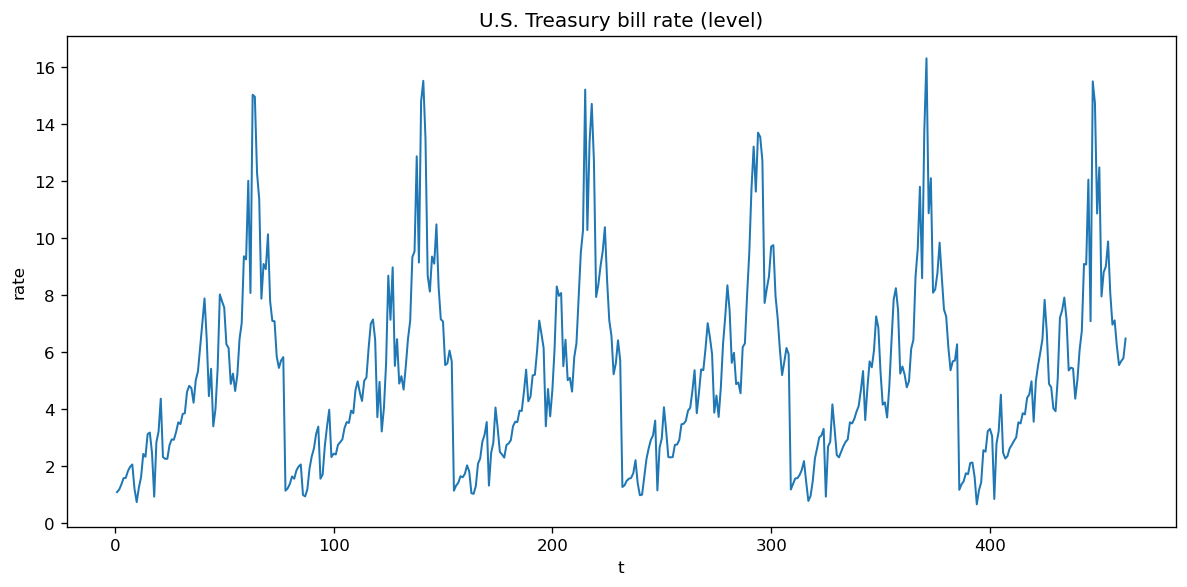

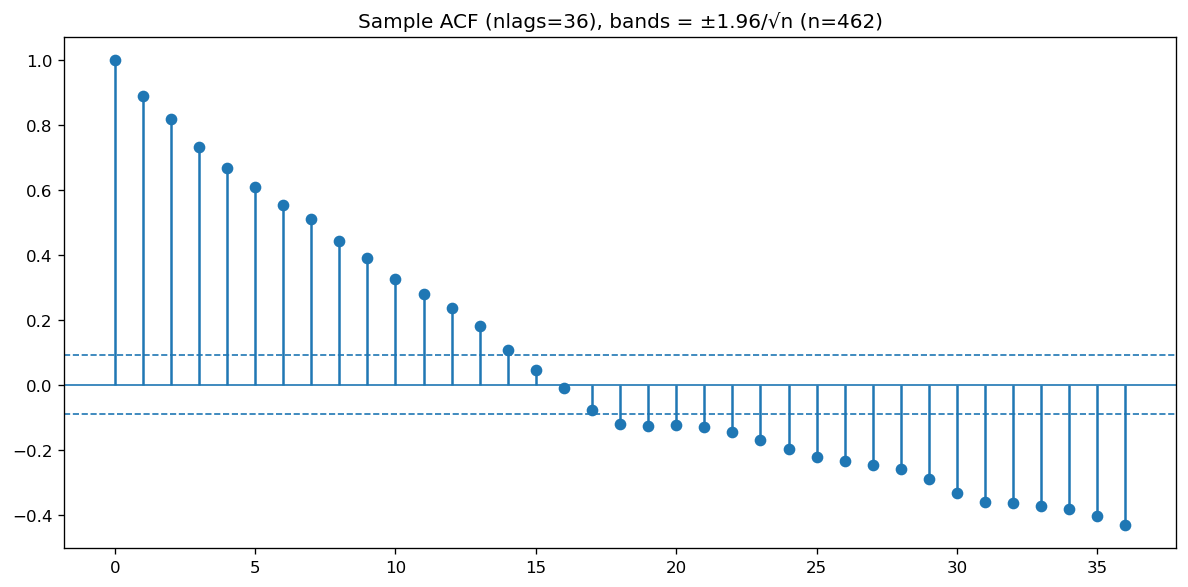

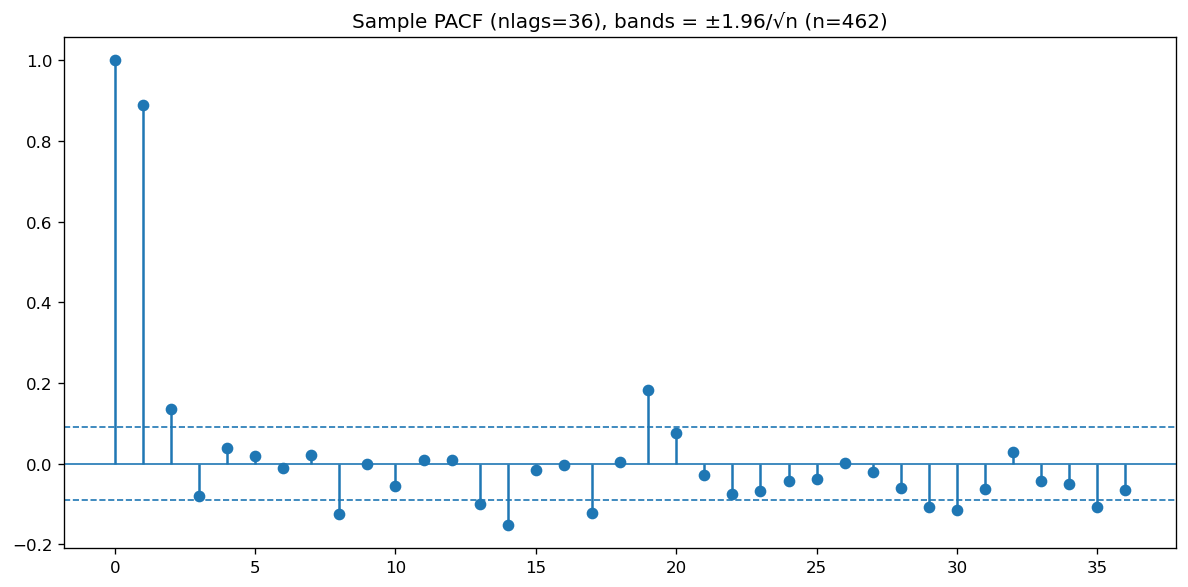

(array([ 1.    ,  0.8883,  0.8178,  0.7318,  0.6681,  0.6094,  0.5552,
         0.5103,  0.442 ,  0.3893,  0.3255,  0.2787,  0.2358,  0.1802,
         0.1073,  0.0444, -0.0088, -0.0764, -0.1212, -0.1271, -0.1246,
        -0.1289, -0.1463, -0.171 , -0.1982, -0.2214, -0.2349, -0.2461,
        -0.2586, -0.2902, -0.333 , -0.362 , -0.3651, -0.374 , -0.3835,
        -0.4053, -0.4321]),
 array([ 1.    ,  0.8883,  0.1362, -0.0807,  0.0396,  0.0197, -0.0101,
         0.0213, -0.1237, -0.001 , -0.0556,  0.0081,  0.0084, -0.101 ,
        -0.1522, -0.015 , -0.003 , -0.1227,  0.004 ,  0.182 ,  0.077 ,
        -0.0276, -0.0746, -0.0667, -0.0432, -0.0379,  0.0009, -0.02  ,
        -0.0596, -0.1062, -0.1154, -0.062 ,  0.0296, -0.0418, -0.0494,
        -0.1063, -0.0658]))

In [4]:
plot_series(ttbill, "U.S. Treasury bill rate (level)", ylabel="rate")
plot_acf_pacf(ttbill, nlags=36)


### Unit root vs trend-stationary diagnosis

For the level series, we use:
- **ADF with constant + trend**: null = unit root,
- **KPSS with trend**: null = trend-stationary.

If ADF rejects the unit root null and KPSS does not reject trend-stationarity, the practical conclusion is that the series is **trend-stationary** rather than difference-stationary.


In [5]:
tests_level = adf_kpss_report(ttbill, regression_adf="ct", regression_kpss="ct")
tests_level


C:\Users\pig_p\AppData\Local\Temp\ipykernel_23736\1350016982.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(yy, regression=regression_kpss, nlags="auto")


,test,statistic,p_value,null
0,ADF,-4.172564,0.004923,unit root
1,KPSS,0.038608,0.100000,stationarity


### Detrend the T-bill series

We fit a linear trend
\[
X_t = \beta_0 + \beta_1 t + Y_t
\]
and treat the residual component \(Y_t\) as the stationary series to be modeled by ARMA.


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     8.364
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00401
Time:                        10:12:17   Log-Likelihood:                -1184.9
No. Observations:                 462   AIC:                             2374.
Df Residuals:                     460   BIC:                             2382.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4382      0.294     15.109      0.0

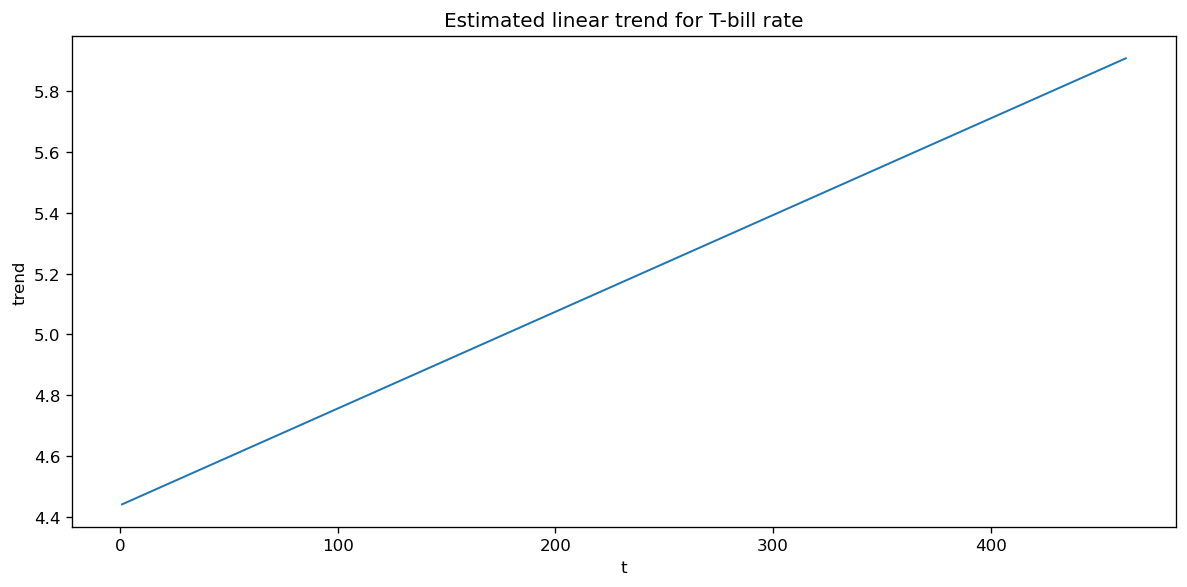

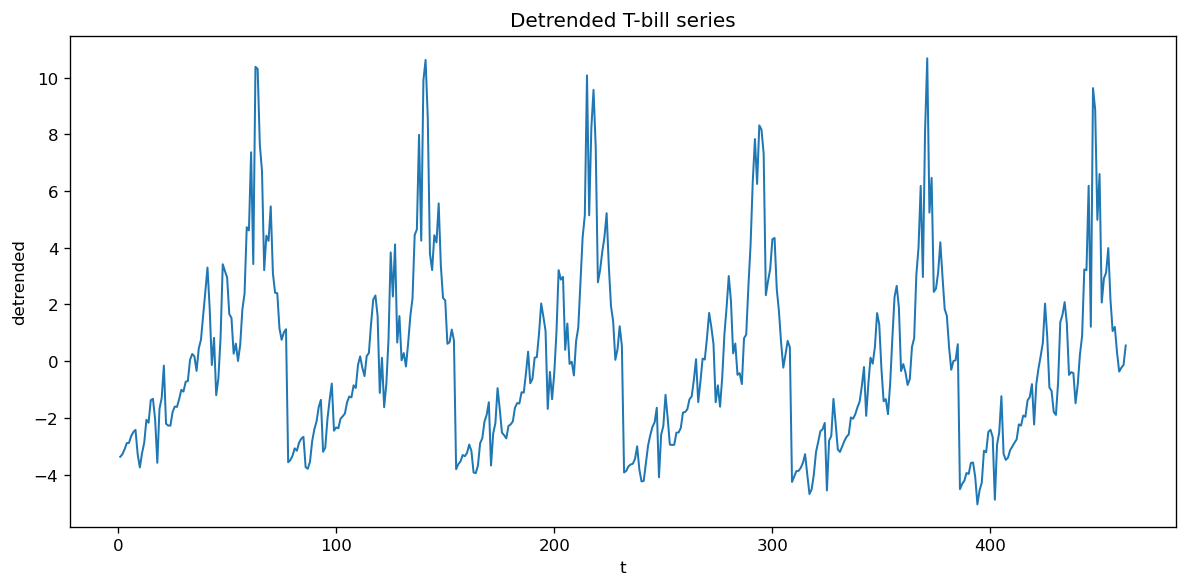

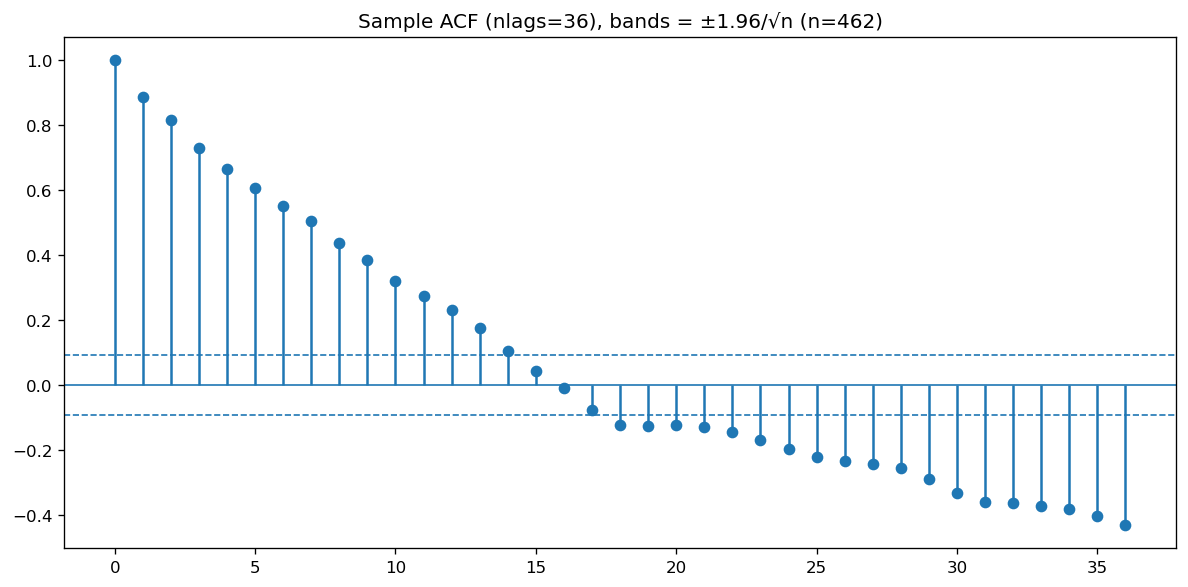

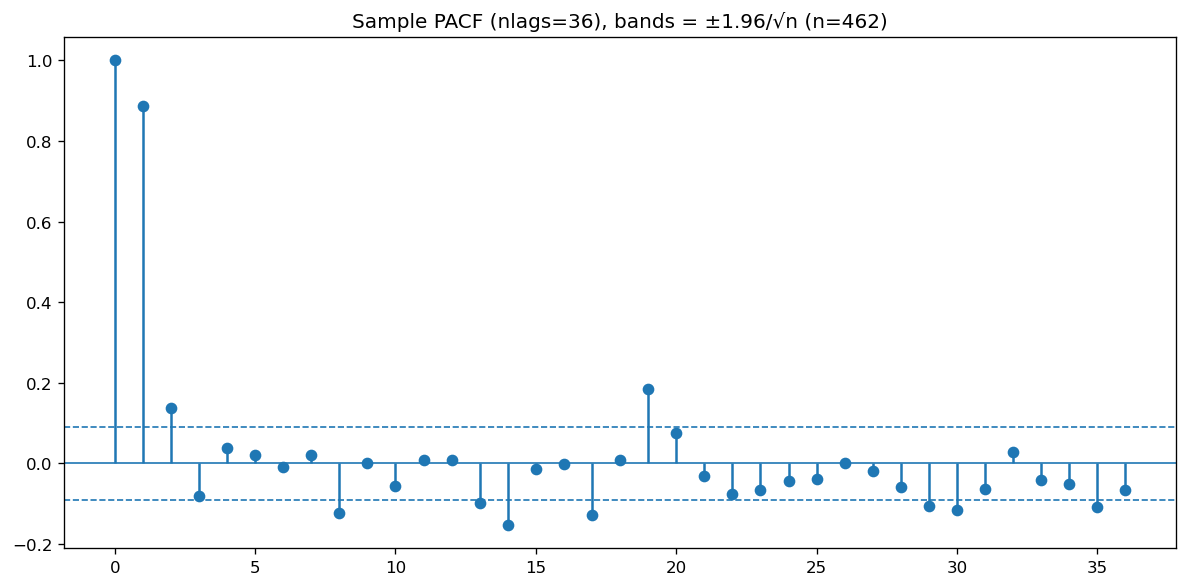

(array([ 1.    ,  0.887 ,  0.8159,  0.7289,  0.6645,  0.6054,  0.551 ,
         0.506 ,  0.4374,  0.385 ,  0.3212,  0.2748,  0.232 ,  0.1769,
         0.104 ,  0.0418, -0.0104, -0.0785, -0.1224, -0.1274, -0.1239,
        -0.128 , -0.1451, -0.1698, -0.1972, -0.2204, -0.2337, -0.2448,
        -0.2569, -0.2883, -0.3313, -0.3602, -0.3631, -0.3723, -0.3822,
        -0.4043, -0.4315]),
 array([ 1.    ,  0.887 ,  0.1364, -0.0817,  0.0393,  0.0202, -0.0096,
         0.0214, -0.1238,  0.0013, -0.0551,  0.0078,  0.0081, -0.0986,
        -0.1528, -0.0126, -0.0006, -0.1286,  0.0078,  0.1836,  0.0751,
        -0.0308, -0.0758, -0.0666, -0.0424, -0.0393,  0.0022, -0.0194,
        -0.0582, -0.1054, -0.1147, -0.0629,  0.0295, -0.041 , -0.0509,
        -0.1089, -0.0655]))

In [6]:
trend_fit, trend_vals, detrended = detrend_linear(ttbill)

print(trend_fit.summary())
plot_series(trend_vals, "Estimated linear trend for T-bill rate", ylabel="trend")
plot_series(detrended, "Detrended T-bill series", ylabel="detrended")
plot_acf_pacf(detrended, nlags=36)


### Re-test stationarity on the detrended component

Once the deterministic trend is removed, the residual series should look stationary.  
Now we use:
- **ADF with constant**,
- **KPSS with level-stationarity**.


In [7]:
tests_detrended = adf_kpss_report(detrended, regression_adf="c", regression_kpss="c")
tests_detrended


C:\Users\pig_p\AppData\Local\Temp\ipykernel_23736\1350016982.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(yy, regression=regression_kpss, nlags="auto")


,test,statistic,p_value,null
0,ADF,-4.145748,0.000813,unit root
1,KPSS,0.038608,0.100000,stationarity


### Box–Jenkins workflow on the detrended series

We fit a grid of ARMA(p,q) models to the detrended component and select the model with the lowest AIC.


In [8]:
best_tbill_fit, tbill_grid, tbill_fits = select_arma_model(detrended, max_p=3, max_q=3, trend="n")
tbill_grid.head(10)


,order,AIC,BIC
0,"(3, 0, 2)",1648.021216,1672.834605
1,"(3, 0, 0)",1648.949993,1665.492252
2,"(2, 0, 1)",1648.997538,1665.539798
3,"(1, 0, 2)",1649.910199,1666.452458
4,"(2, 0, 0)",1650.045692,1662.452386
5,"(1, 0, 3)",1650.198078,1670.875902
6,"(2, 0, 2)",1650.435016,1671.112841
7,"(3, 0, 1)",1650.533685,1671.211510
8,"(1, 0, 1)",1651.471233,1663.877928
9,"(2, 0, 3)",1652.099691,1676.913081


In [9]:
print(best_tbill_fit.summary())

tbill_resid, tbill_lb = residual_report(best_tbill_fit, lags=(6, 12, 18, 24))
tbill_lb


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  462
Model:                 ARIMA(3, 0, 2)   Log Likelihood                -818.011
Date:                Sat, 04 Apr 2026   AIC                           1648.021
Time:                        10:12:21   BIC                           1672.835
Sample:                             0   HQIC                          1657.790
                                - 462                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7308      0.140     -5.215      0.000      -1.005      -0.456
ar.L2          0.6850      0.077      8.929      0.000       0.535       0.835
ar.L3          0.7180      0.110      6.511      0.0

,lb_stat,lb_pvalue
6,0.890041,0.989439
12,6.908365,0.863609
18,43.784514,0.000619
24,47.754604,0.002707


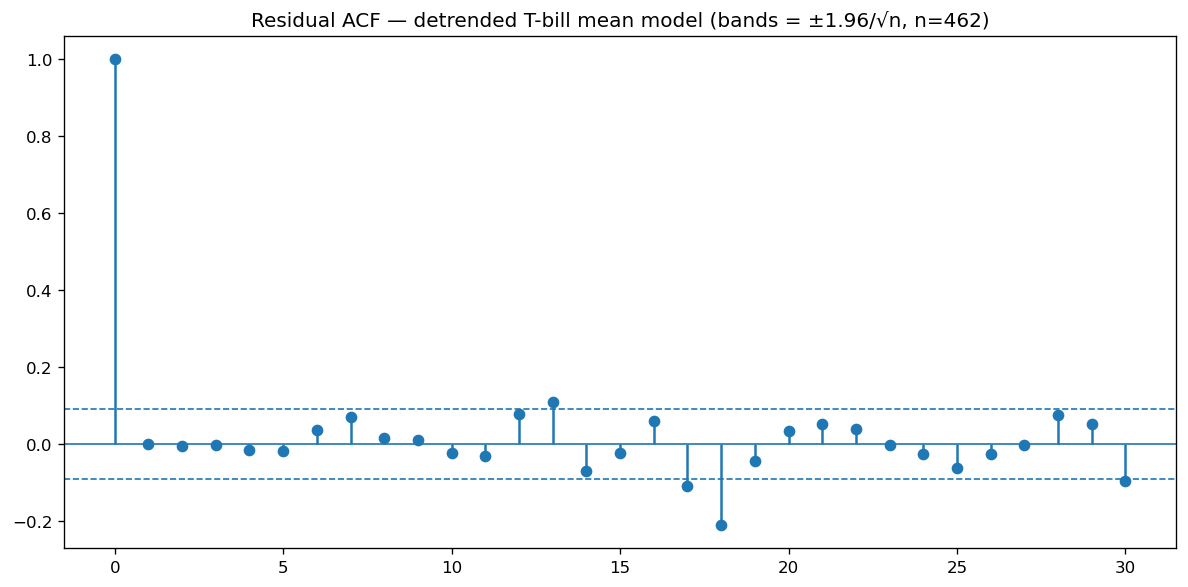

In [10]:
plot_resid_acf(tbill_resid, nlags=30, title="Residual ACF — detrended T-bill mean model")


### Holdout forecasting on the original T-bill series

To illustrate the full workflow, we do a holdout forecast of the **original series**:

1. fit the linear trend on the training sample,
2. fit the ARMA model to the detrended training residuals,
3. forecast the residual component,
4. add back the extrapolated deterministic trend.

This gives forecasts directly on the original T-bill series.


In [11]:
h = 12
y_train = ttbill[:-h]
y_test = ttbill[-h:]

trend_fit_tr, trend_tr, detr_tr = detrend_linear(y_train)
best_fit_tr, grid_tr, fits_tr = select_arma_model(detr_tr, max_p=3, max_q=3, trend="n")

print("Selected ARMA order on detrended training series:", grid_tr.iloc[0]["order"])
print(best_fit_tr.summary())


Selected ARMA order on detrended training series: (2, 0, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  450
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -800.436
Date:                Sat, 04 Apr 2026   AIC                           1608.871
Time:                        10:12:24   BIC                           1625.308
Sample:                             0   HQIC                          1615.349
                                - 450                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3335      0.160      2.080      0.037       0.019       0.648
ar.L2          0.5288      0.140      3.764      0.000       0.253     

In [12]:
fc = best_fit_tr.get_forecast(steps=h)
mean_resid_fc = np.asarray(fc.predicted_mean)

t_full = np.arange(1, len(y_train) + h + 1)
X_full = sm.add_constant(t_full)
trend_pred_full = trend_fit_tr.predict(X_full)
trend_future = trend_pred_full[-h:]

y_fc = trend_future + mean_resid_fc

forecast_df_tbill = pd.DataFrame({
    "Actual": y_test,
    "Forecast": y_fc,
    "Trend": trend_future,
    "Residual forecast": mean_resid_fc
}, index=np.arange(len(ttbill) - h + 1, len(ttbill) + 1))

forecast_df_tbill.head()


,Actual,Forecast,Trend,Residual forecast
451,7.94,11.555913,5.722241,5.833673
452,8.79,11.240262,5.724920,5.515343
453,9.00,10.651974,5.727598,4.924376
454,9.87,10.289220,5.730277,4.558943
455,8.06,9.857510,5.732956,4.124554


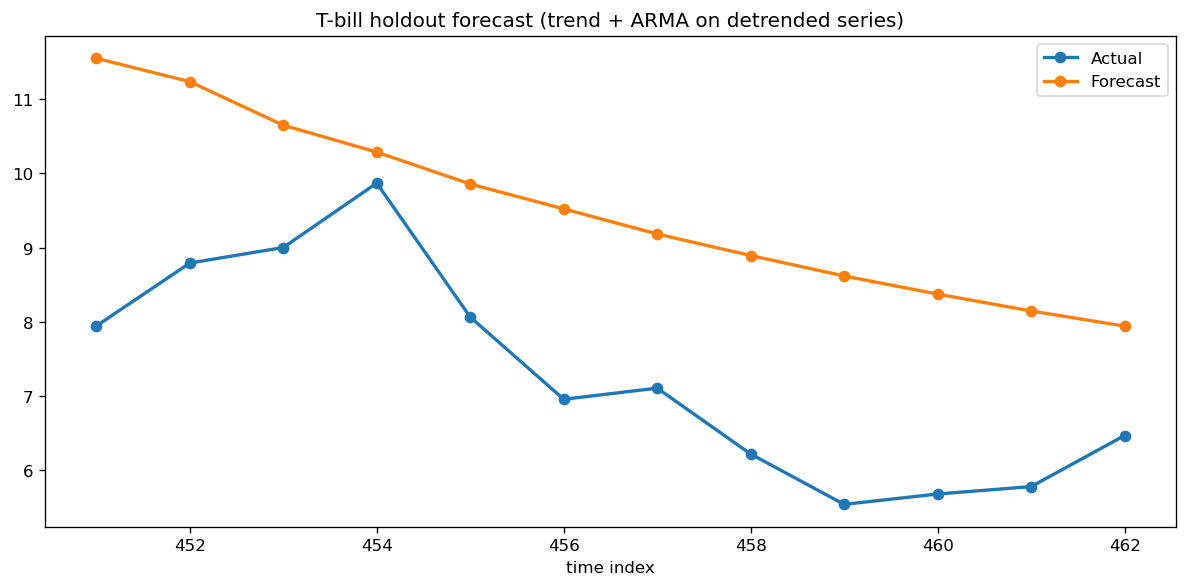

In [13]:
plt.figure(figsize=(10, 5))
idx = forecast_df_tbill.index.values
plt.plot(idx, forecast_df_tbill["Actual"].values, marker="o", linewidth=2, label="Actual")
plt.plot(idx, forecast_df_tbill["Forecast"].values, marker="o", linewidth=2, label="Forecast")
plt.title("T-bill holdout forecast (trend + ARMA on detrended series)")
plt.xlabel("time index")
plt.tight_layout()
plt.legend()
plt.show()


### Interpretation

The key lesson is not the exact numerical forecast, but the **workflow choice**:

- the tests support **trend-stationarity** rather than a pure unit-root story,
- therefore **detrending** is more appropriate than differencing,
- Box–Jenkins should then be applied to the detrended residual component,
- final forecasts for the original series are obtained by adding the forecasted residual component back to the extrapolated trend.


## Example 2: Exchange rates (`exchange.dat`)

### Data and modeling question
This example illustrates a more complete mean–variance workflow.

For exchange rates, the practical modeling path is typically:
1. work with **log prices** and then **log returns**,
2. model the **conditional mean** of returns,
3. test whether the mean-model residuals have ARCH effects,
4. fit **ARCH(q)** or **GARCH(p,q)** to the residuals,
5. forecast both
   - the **future return volatility**,
   - and the **original exchange-rate series**.

This is more faithful to practice than modeling volatility alone.


In [14]:
exchange = np.loadtxt("exchange.dat").astype(float)
log_exchange = np.log(exchange)
ret = np.diff(log_exchange)

len(exchange), exchange[:5], exchange[-5:]


(470,
 array([2.24, 2.26, 2.29, 2.26, 2.27]),
 array([1.86, 1.85, 1.81, 1.8 , 1.81]))

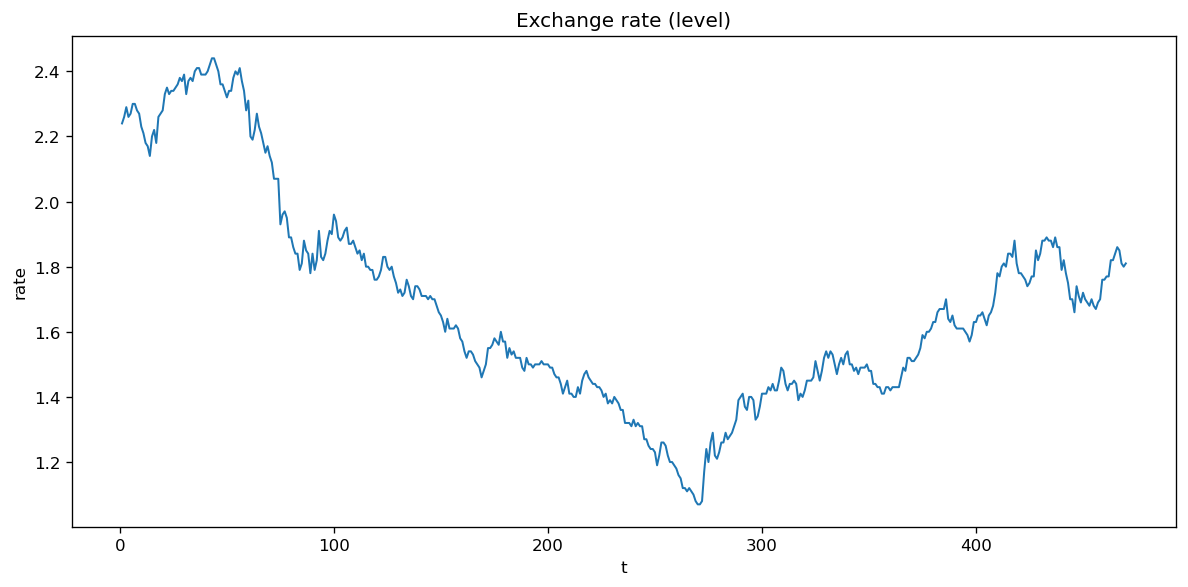

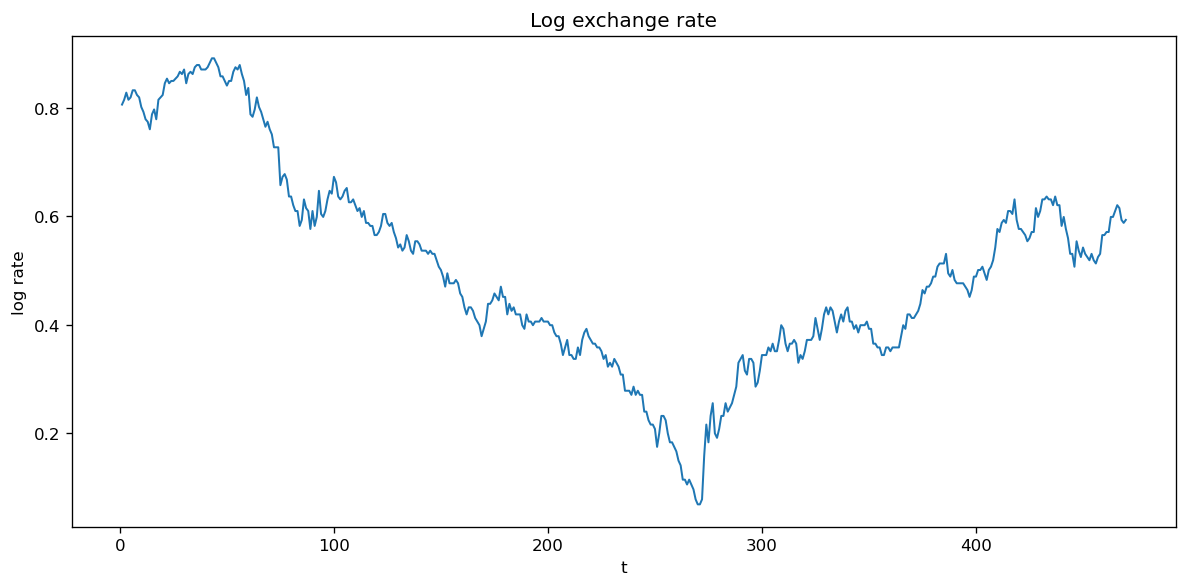

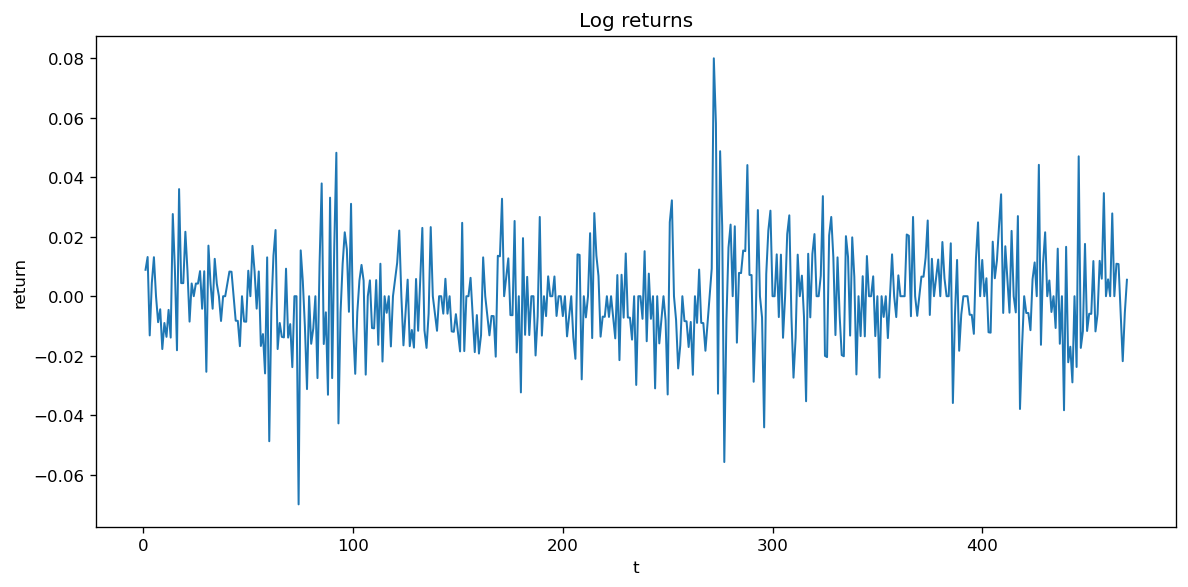

In [15]:
plot_series(exchange, "Exchange rate (level)", ylabel="rate")
plot_series(log_exchange, "Log exchange rate", ylabel="log rate")
plot_series(ret, "Log returns", ylabel="return")


### Stationarity diagnostics

For the **log-level** series:
- ADF with trend,
- KPSS with trend.

For the **return** series:
- ADF with constant,
- KPSS with constant.

We expect the level to behave like a nonstationary series, while returns should be much closer to stationary.


In [16]:
tests_log_level = adf_kpss_report(log_exchange, regression_adf="ct", regression_kpss="ct")
tests_returns = adf_kpss_report(ret, regression_adf="c", regression_kpss="c")

print("Log-level tests:")
display(tests_log_level)

print("Return tests:")
display(tests_returns)


Log-level tests:


C:\Users\pig_p\AppData\Local\Temp\ipykernel_23736\1350016982.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(yy, regression=regression_kpss, nlags="auto")


,test,statistic,p_value,null
0,ADF,-0.704422,0.972856,unit root
1,KPSS,0.852137,0.010000,stationarity


Return tests:


,test,statistic,p_value,null
0,ADF,-22.296408,0.000000,unit root
1,KPSS,0.537062,0.033319,stationarity


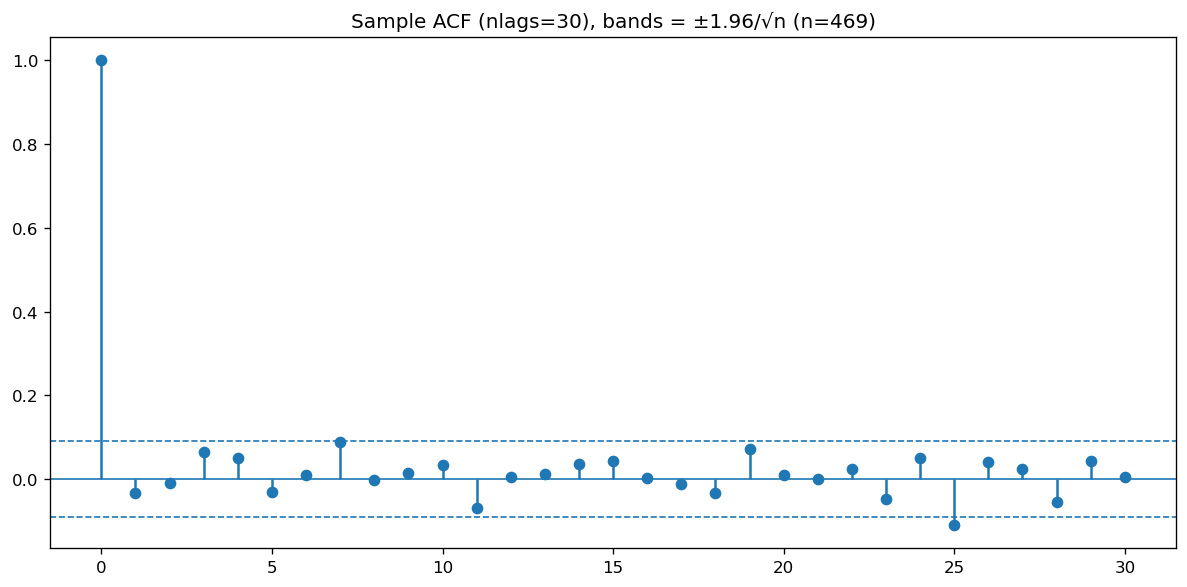

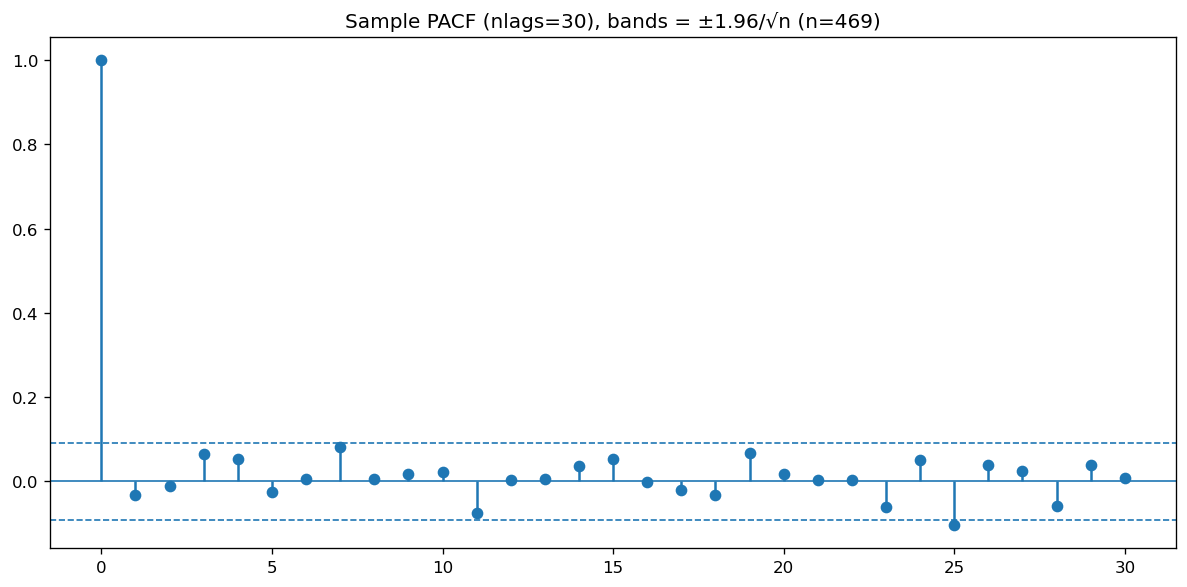

(array([ 1.    , -0.0321, -0.0098,  0.0646,  0.0493, -0.0307,  0.0099,
         0.0878, -0.0023,  0.0137,  0.0335, -0.0685,  0.0057,  0.0119,
         0.0352,  0.0431,  0.0025, -0.0108, -0.0341,  0.0712,  0.0088,
        -0.0001,  0.023 , -0.0473,  0.0492, -0.1099,  0.0399,  0.0248,
        -0.0559,  0.0423,  0.0059]),
 array([ 1.    , -0.0321, -0.0108,  0.064 ,  0.0536, -0.0262,  0.0046,
         0.0819,  0.0047,  0.0168,  0.0226, -0.0755,  0.004 ,  0.0055,
         0.0361,  0.0541, -0.0026, -0.0195, -0.0333,  0.0662,  0.0181,
         0.0042,  0.003 , -0.0605,  0.0508, -0.1038,  0.0378,  0.0249,
        -0.0579,  0.0383,  0.0078]))

In [17]:
plot_acf_pacf(ret, nlags=30)


### Mean model for returns

We first fit an ARMA model to the return series.  
This is the **conditional mean** part of the workflow.

If the best model is close to white noise, that is itself informative:  
it means predictability lies mostly in the **conditional variance**, not the conditional mean.


In [18]:
best_mean_fit, mean_grid, mean_fits = select_arma_model(ret, max_p=2, max_q=2, trend="c")
mean_grid


C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Miniconda3\envs\ds\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,order,AIC,BIC
0,"(0, 0, 0)",-2508.880161,-2500.578955
1,"(0, 0, 1)",-2507.370921,-2494.919113
2,"(1, 0, 0)",-2507.363541,-2494.911733
3,"(2, 0, 0)",-2505.417904,-2488.815493
4,"(0, 0, 2)",-2505.382489,-2488.780078
5,"(1, 0, 1)",-2505.134563,-2488.532152
6,"(2, 0, 2)",-2503.830478,-2478.926861
7,"(2, 0, 1)",-2503.408322,-2482.655308
8,"(1, 0, 2)",-2503.335681,-2482.582667


In [19]:
print(best_mean_fit.summary())

mean_resid, mean_lb = residual_report(best_mean_fit, lags=(6, 12, 18, 24))
print("Ljung–Box on mean-model residuals:")
mean_lb


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  469
Model:                          ARIMA   Log Likelihood                1256.440
Date:                Sat, 04 Apr 2026   AIC                          -2508.880
Time:                        10:12:29   BIC                          -2500.579
Sample:                             0   HQIC                         -2505.614
                                - 469                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0005      0.001     -0.595      0.552      -0.002       0.001
sigma2         0.0003   1.27e-05     21.624      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.49   Jarque-

,lb_stat,lb_pvalue
6,4.159573,0.655092
12,10.753658,0.550140
18,12.954294,0.794281
24,18.051777,0.800489


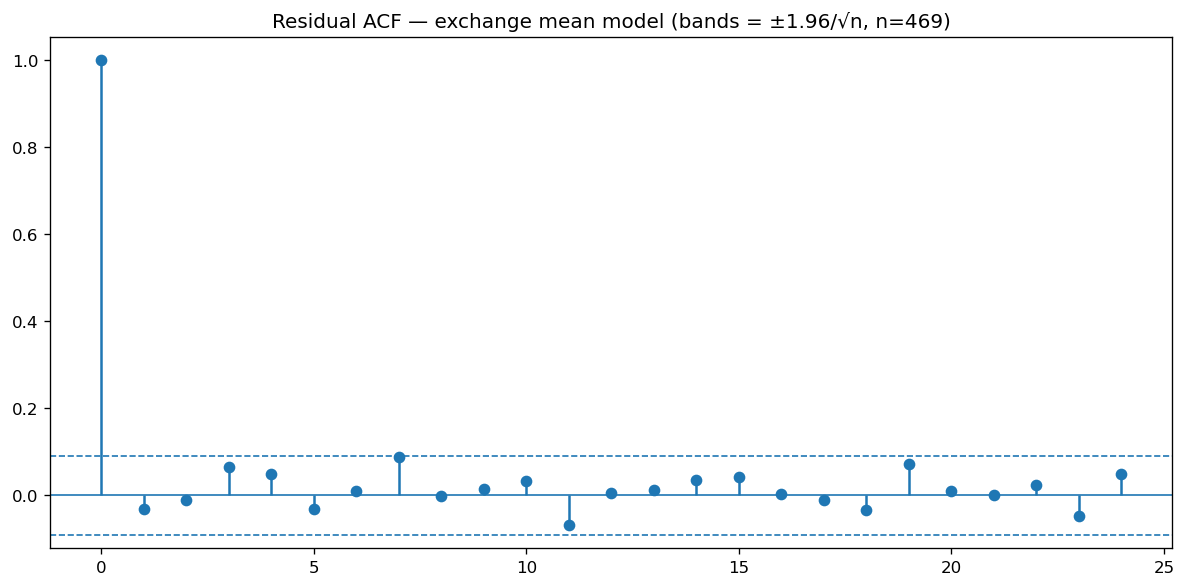

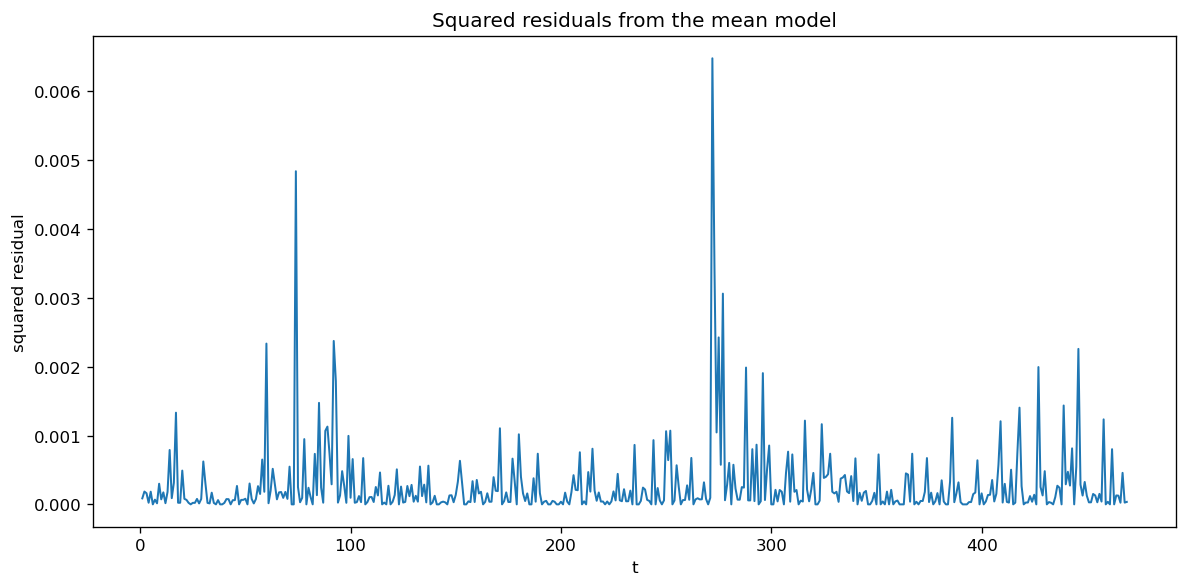

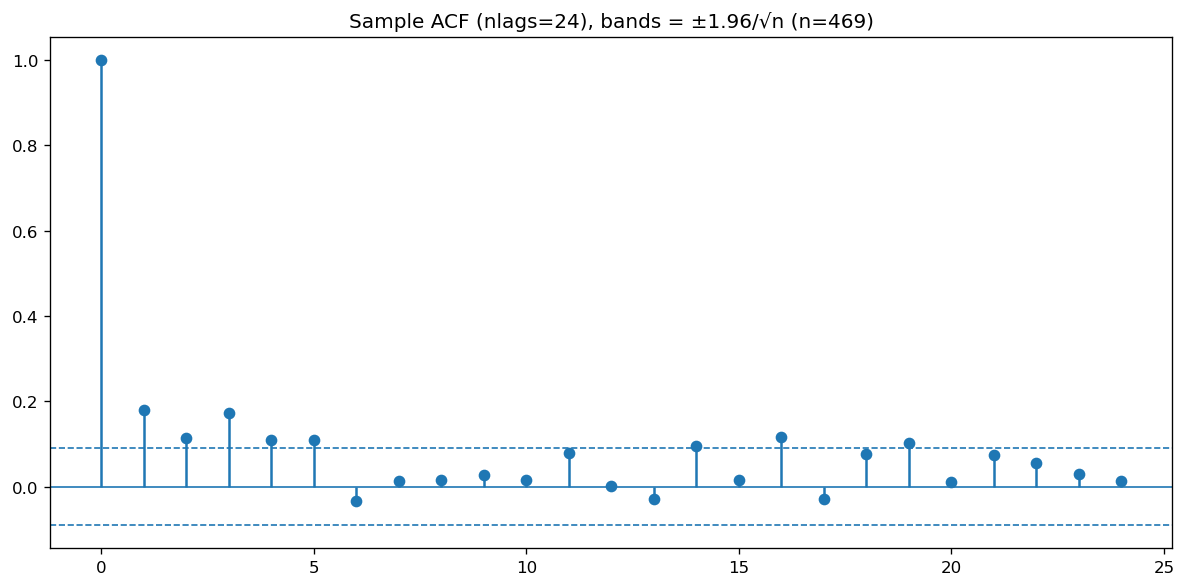

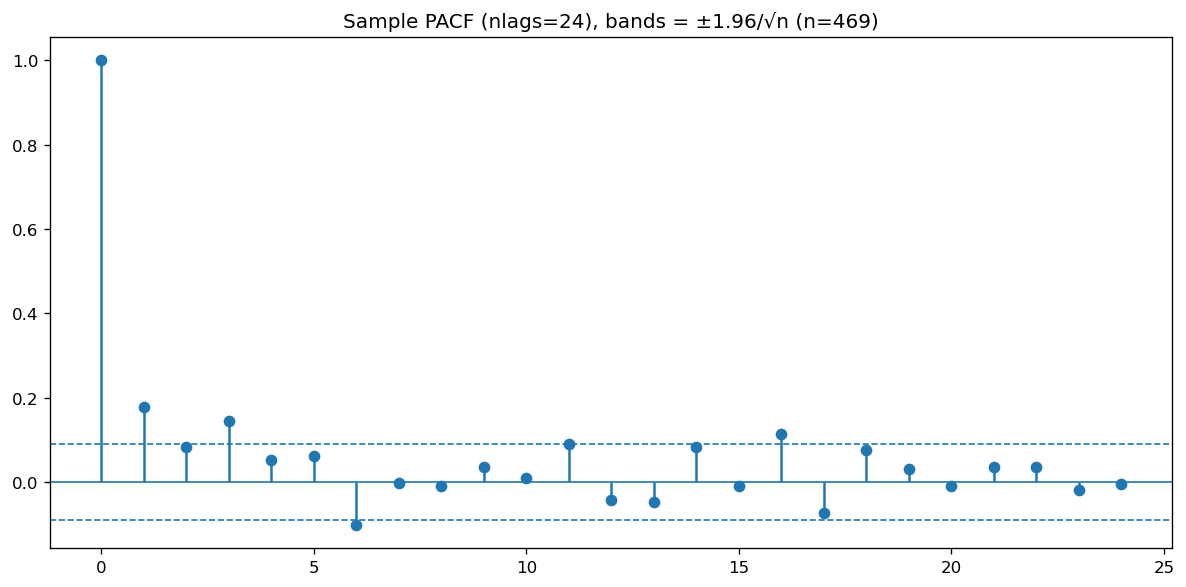

(array([ 1.    ,  0.1791,  0.1132,  0.1733,  0.1086,  0.1093, -0.0351,
         0.0128,  0.0152,  0.0262,  0.0152,  0.079 ,  0.0012, -0.0299,
         0.0955,  0.0157,  0.1151, -0.0282,  0.0751,  0.1029,  0.0109,
         0.0734,  0.0549,  0.0299,  0.0126]),
 array([ 1.    ,  0.1791,  0.0838,  0.1453,  0.0526,  0.0627, -0.1017,
        -0.003 , -0.0082,  0.0365,  0.0097,  0.0911, -0.0415, -0.0459,
         0.0833, -0.0099,  0.1148, -0.074 ,  0.0773,  0.0314, -0.0092,
         0.0355,  0.0354, -0.0185, -0.0049]))

In [20]:
plot_resid_acf(mean_resid, nlags=24, title="Residual ACF — exchange mean model")
plot_series(mean_resid**2, "Squared residuals from the mean model", ylabel="squared residual")
plot_acf_pacf(mean_resid**2, nlags=24)


### Test for ARCH effects

If squared residuals show serial dependence, we should move beyond the mean model and fit a volatility model.

We use an ARCH-LM test on the mean-model residuals.


In [21]:
arch_test = arch_lm_test(mean_resid, nlags=12)
pd.DataFrame([arch_test])


,LM statistic,df,p_value
0,38.870266,12,0.000111


### ARCH / GARCH with user-specified orders

The earlier version of the lab fixed ARCH(1) and GARCH(1,1).  
Here the user can specify:

- `arch_q`: number of ARCH lags,
- `garch_p`: number of GARCH lags,
- `garch_q`: number of ARCH lags inside the GARCH model.

You can change these numbers and rerun the cell.


In [22]:
arch_q = 3
garch_p = 1
garch_q = 1

arch_fit = fit_arch_model(mean_resid, q=arch_q)
garch_fit = fit_garch_model(mean_resid, p=garch_p, q=garch_q)

vol_compare = pd.DataFrame({
    "model": [arch_fit["model"], garch_fit["model"]],
    "AIC": [arch_fit["AIC"], garch_fit["AIC"]],
    "success": [arch_fit["success"], garch_fit["success"]]
}).sort_values("AIC")

vol_compare


,model,AIC,success
1,"GARCH(1,1)",-3391.533645,True
0,ARCH(3),-3382.929474,True


In [23]:
print("ARCH fit:")
print("params =", arch_fit["params"])
print("success =", arch_fit["success"], "|", arch_fit["message"])

print("\nGARCH fit:")
print("params =", garch_fit["params"])
print("success =", garch_fit["success"], "|", garch_fit["message"])


ARCH fit:
params = [0.0002 0.0333 0.0333 0.0333]
success = True | CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

GARCH fit:
params = [0.   0.05 0.85]
success = True | CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


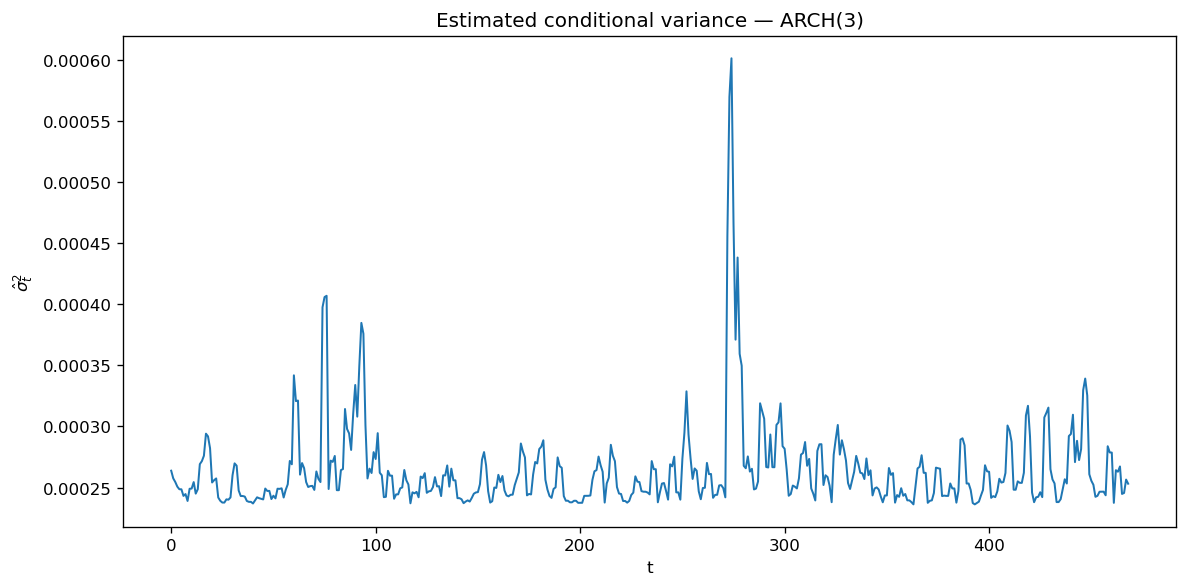

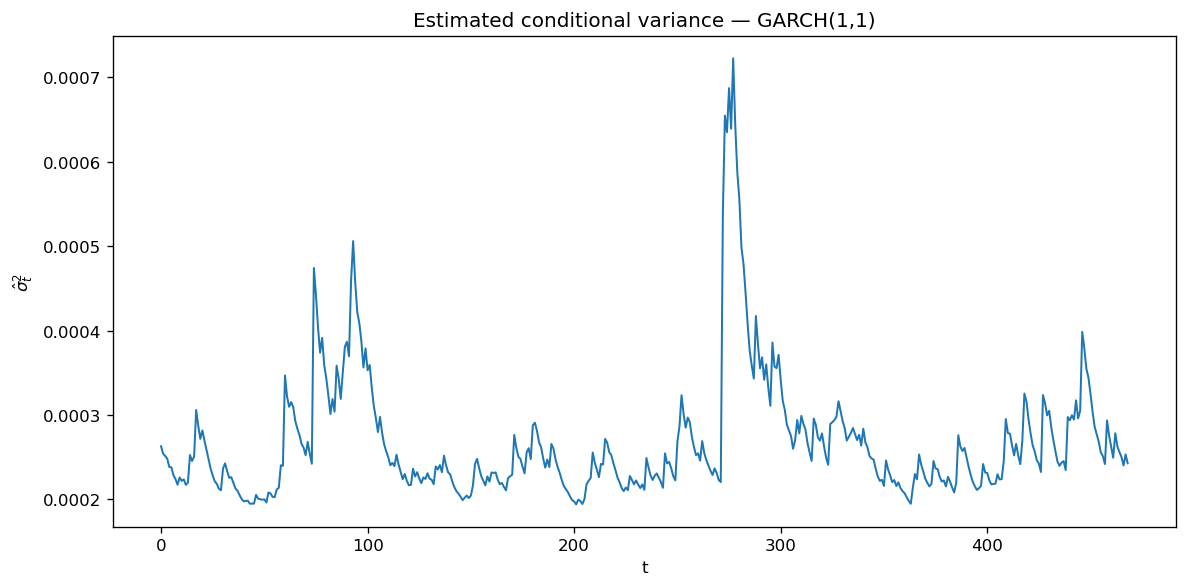

In [24]:
plot_conditional_variance(arch_fit["sig2"], title=f"Estimated conditional variance — {arch_fit['model']}")
plot_conditional_variance(garch_fit["sig2"], title=f"Estimated conditional variance — {garch_fit['model']}")


### Choose a volatility model and forecast both mean and variance

We now combine:
- the **mean forecast** from the ARMA model on returns,
- the **variance forecast** from the chosen ARCH/GARCH model.

Then we reconstruct forecasts for the **original exchange-rate series** from the return forecasts.


In [25]:
use_garch = vol_compare.iloc[0]["model"].startswith("GARCH")

h = 12
mean_fc_obj = best_mean_fit.get_forecast(steps=h)
mean_ret_fc = np.asarray(mean_fc_obj.predicted_mean)

if use_garch:
    var_fc = forecast_garch_variance(
        garch_fit["params"], mean_resid, garch_fit["sig2"],
        p=garch_p, q=garch_q, h=h
    )
    chosen_vol_model = garch_fit["model"]
else:
    var_fc = forecast_arch_variance(arch_fit["params"], mean_resid, q=arch_q, h=h)
    chosen_vol_model = arch_fit["model"]

sigma_fc = np.sqrt(var_fc)
print("Chosen volatility model:", chosen_vol_model)


Chosen volatility model: GARCH(1,1)


In [26]:
last_log_price = log_exchange[-1]
cum_mean = np.cumsum(mean_ret_fc)
log_price_fc = last_log_price + cum_mean
exchange_fc = np.exp(log_price_fc)

forecast_exchange = pd.DataFrame({
    "mean_return_forecast": mean_ret_fc,
    "variance_forecast": var_fc,
    "volatility_forecast": sigma_fc,
    "exchange_rate_forecast": exchange_fc
}, index=np.arange(len(exchange) + 1, len(exchange) + h + 1))

forecast_exchange


,mean_return_forecast,variance_forecast,volatility_forecast,exchange_rate_forecast
471,-0.000459,0.000234,0.015307,1.809169
472,-0.000459,0.000237,0.015398,1.808338
473,-0.000459,0.000240,0.015479,1.807507
474,-0.000459,0.000242,0.015552,1.806677
475,-0.000459,0.000244,0.015617,1.805847
476,-0.000459,0.000246,0.015675,1.805017
477,-0.000459,0.000247,0.015727,1.804188
478,-0.000459,0.000249,0.015774,1.803359
479,-0.000459,0.000250,0.015817,1.802531
480,-0.000459,0.000251,0.015854,1.801703


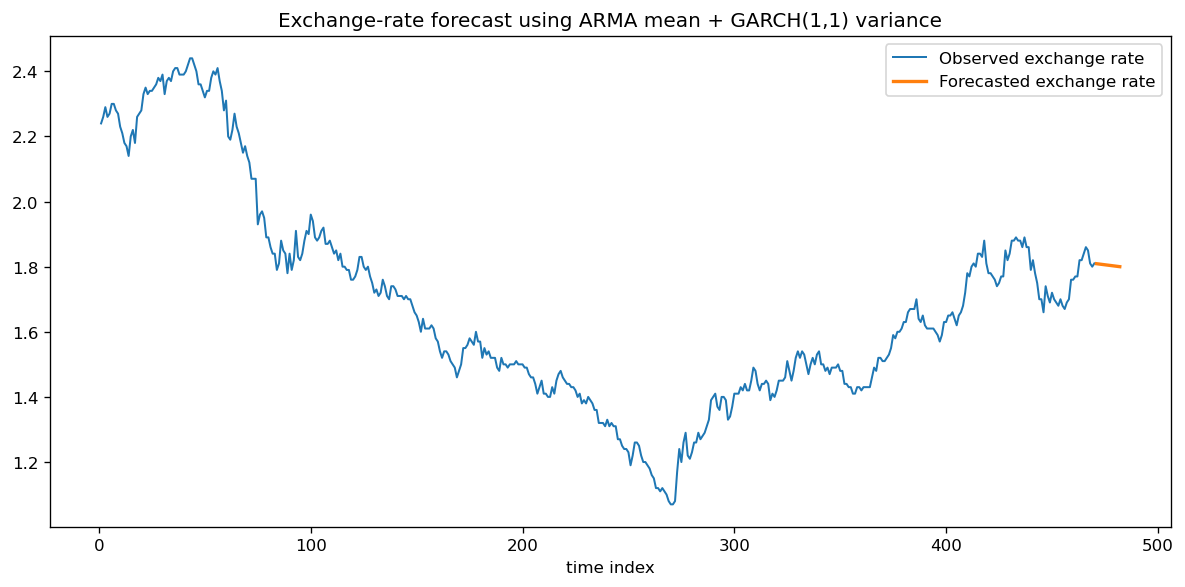

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(exchange) + 1), exchange, linewidth=1.2, label="Observed exchange rate")
plt.plot(forecast_exchange.index.values, forecast_exchange["exchange_rate_forecast"].values,
         linewidth=2, label="Forecasted exchange rate")
plt.title(f"Exchange-rate forecast using ARMA mean + {chosen_vol_model} variance")
plt.xlabel("time index")
plt.tight_layout()
plt.legend()
plt.show()


### Interpretation

This second example now follows the full workflow:

1. decide how to transform the original series;
2. fit the **conditional mean** model;
3. diagnose heteroskedasticity from the mean-model residuals;
4. fit **ARCH / GARCH** to the residuals;
5. forecast both
   - the **future return variance**,
   - and the **original exchange rate**.

This is the practical lesson:  
for financial time series, forecasting the original series often requires **both** a mean model and a volatility model.


## Final remarks

- For the T-bill example, the main revision is the decision to treat the series as **trend-stationary** and to apply Box–Jenkins after detrending.
- For the exchange-rate example, the main revision is to treat the problem **holistically**:
  mean modeling + heteroskedasticity diagnostics + volatility modeling + reconstruction of original-series forecasts.

You can extend this notebook by:
- enlarging the ARMA grid,
- trying different ARCH/GARCH orders,
- comparing holdout forecast errors,
- and adding prediction intervals for the reconstructed original series.
